c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0:	learn: 0.2683760	test: 0.2727128	best: 0.2727128 (0)	total: 136ms	remaining: 20.2s
50:	learn: 0.2231303	test: 0.2271613	best: 0.2271613 (50)	total: 201ms	remaining: 389ms
100:	learn: 0.1740555	test: 0.1775717	best: 0.1775717 (100)	total: 263ms	remaining: 128ms
149:	learn: 0.1474896	test: 0.1506834	best: 0.1506834 (149)	total: 324ms	remaining: 0us

bestTest = 0.1506833838
bestIteration = 149


🔹 CatBoost Conductivity Regression Metrics:
✅ R²: 0.6849
✅ RMSE: 0.1491
✅ MAE: 0.1124
✅ MAPE: 0.18%


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


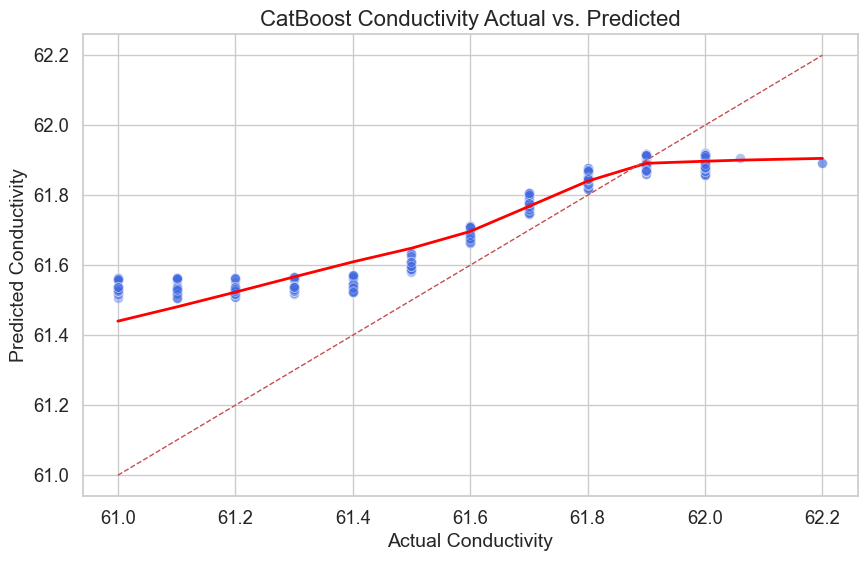

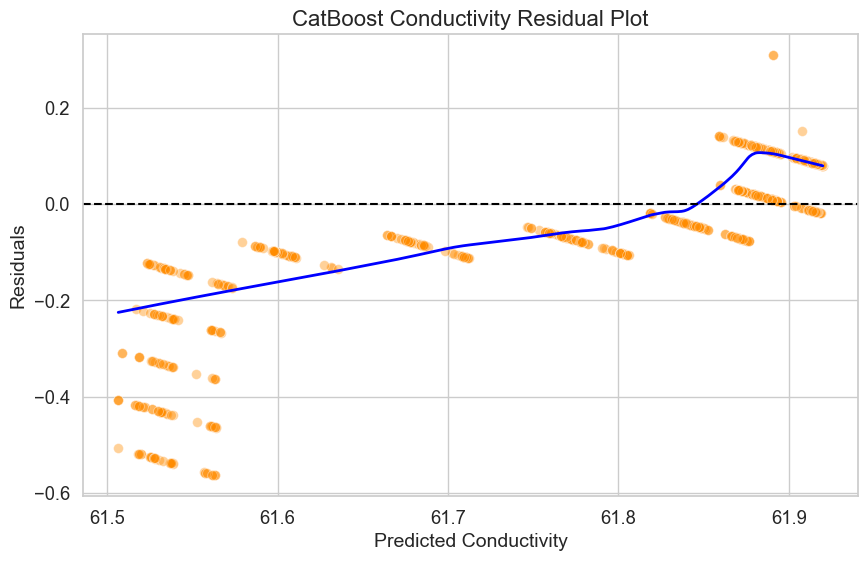

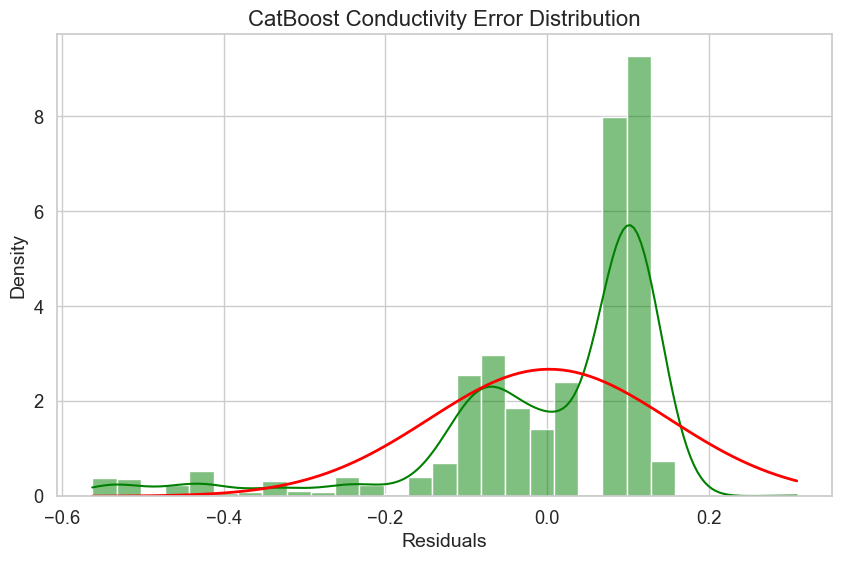

{'learn': {'RMSE': [0.26837598132297097, 0.2682445151913216, 0.2682412630108988, 0.26823301513487857, 0.2652444830127658, 0.26219536660463466, 0.2621748212254525, 0.26214895827269874, 0.26202423944238434, 0.26190314782508156, 0.26187035740814896, 0.2618478772065433, 0.261763450518243, 0.2617298428852815, 0.2587969247868176, 0.2558476619964265, 0.25573513468146575, 0.25573015092769324, 0.2556209485674936, 0.2555149272582784, 0.25541199558109157, 0.252522056075348, 0.24968502434743897, 0.24958777339639784, 0.2468042383219226, 0.24679017908521286, 0.24407241814654057, 0.24403980925063037, 0.24401977358351862, 0.24399677879685297, 0.24396596187385594, 0.2438756215050725, 0.24378791766077718, 0.24112497294195218, 0.2385114794762468, 0.2384859261706415, 0.23846988691170481, 0.23845877870626295, 0.235894599167694, 0.2333125115553427, 0.2332321803246483, 0.23315419552322134, 0.23314231850297096, 0.2330942420888906, 0.2330699277922364, 0.23053138278253124, 0.23051692966166545, 0.228026185285459

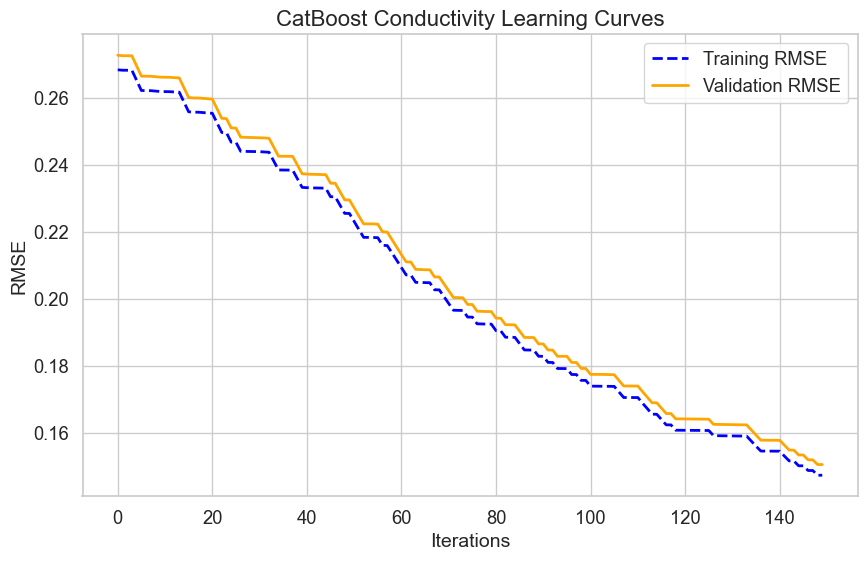

0:	learn: 0.2683893	test: 0.2727283	best: 0.2727283 (0)	total: 1.91ms	remaining: 285ms
50:	learn: 0.2369749	test: 0.2411263	best: 0.2411263 (50)	total: 80.3ms	remaining: 156ms
100:	learn: 0.1995415	test: 0.2033623	best: 0.2033623 (100)	total: 148ms	remaining: 71.8ms
149:	learn: 0.1776766	test: 0.1812660	best: 0.1812660 (149)	total: 216ms	remaining: 0us

bestTest = 0.1812659943
bestIteration = 149

0:	learn: 0.2682844	test: 0.2726061	best: 0.2726061 (0)	total: 1.37ms	remaining: 205ms
50:	learn: 0.1513174	test: 0.1546006	best: 0.1546006 (50)	total: 62.8ms	remaining: 122ms
100:	learn: 0.0753921	test: 0.0771360	best: 0.0771360 (100)	total: 121ms	remaining: 58.9ms
149:	learn: 0.0490202	test: 0.0499817	best: 0.0499817 (149)	total: 180ms	remaining: 0us

bestTest = 0.0499816871
bestIteration = 149

0:	learn: 0.2681591	test: 0.2724591	best: 0.2724591 (0)	total: 1.23ms	remaining: 183ms
50:	learn: 0.0919508	test: 0.0939629	best: 0.0939629 (50)	total: 79.3ms	remaining: 154ms
100:	learn: 0.0286398	

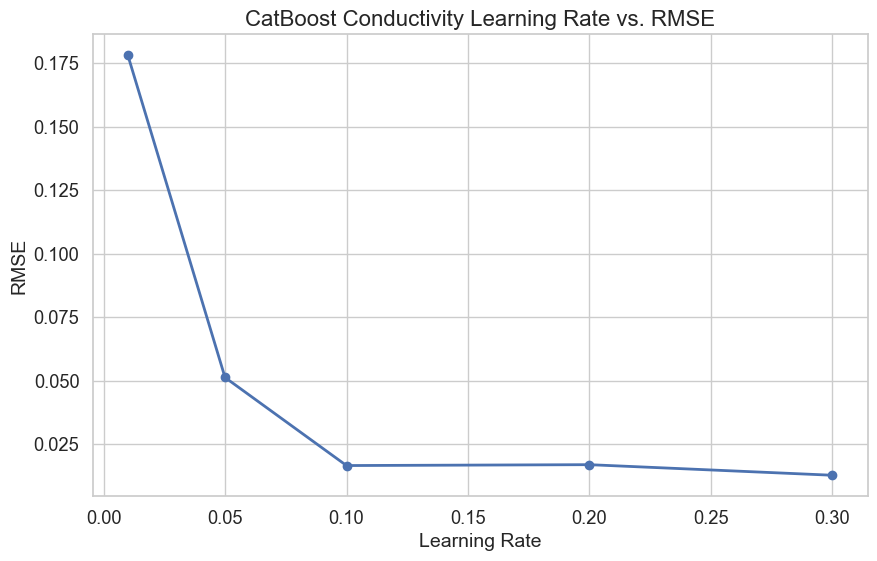

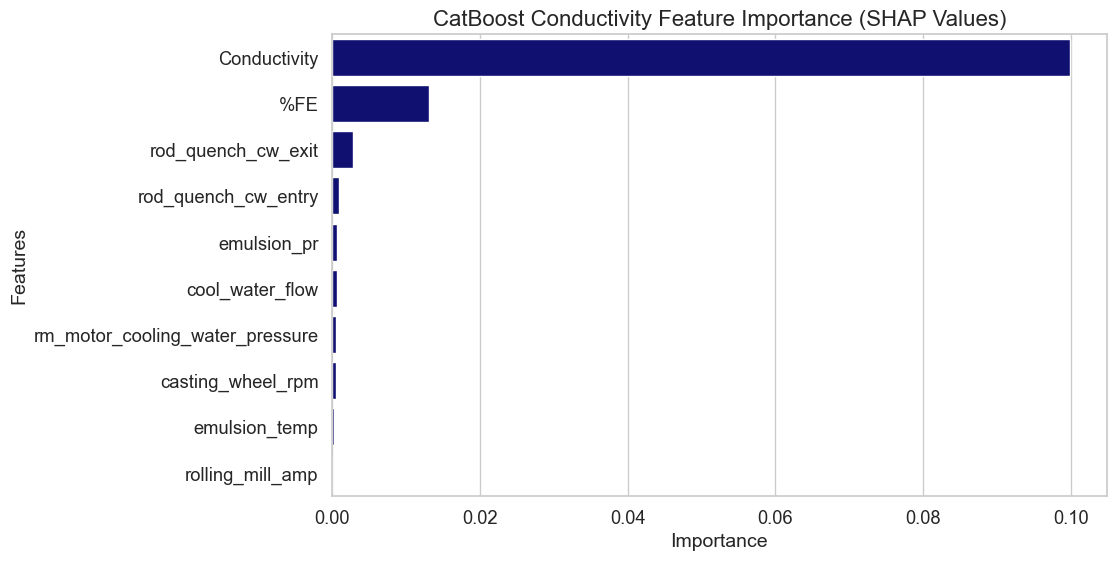

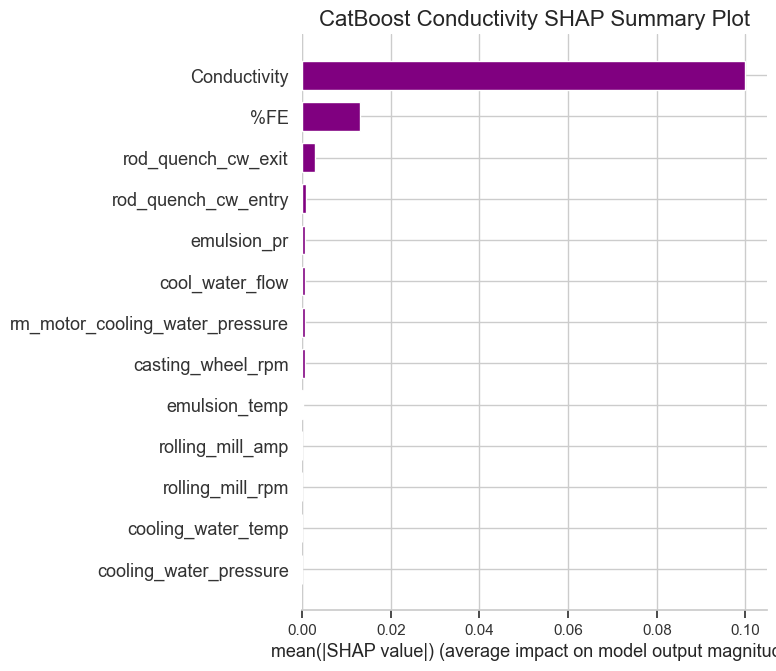

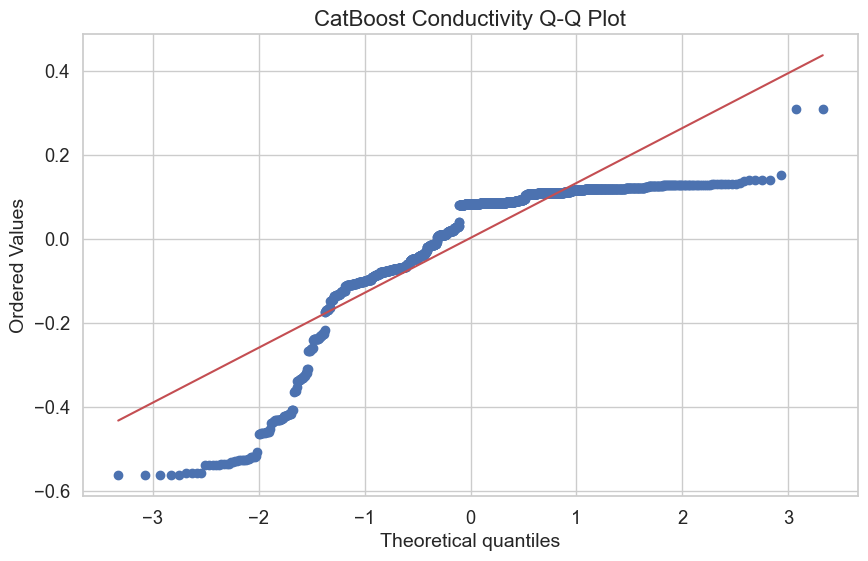

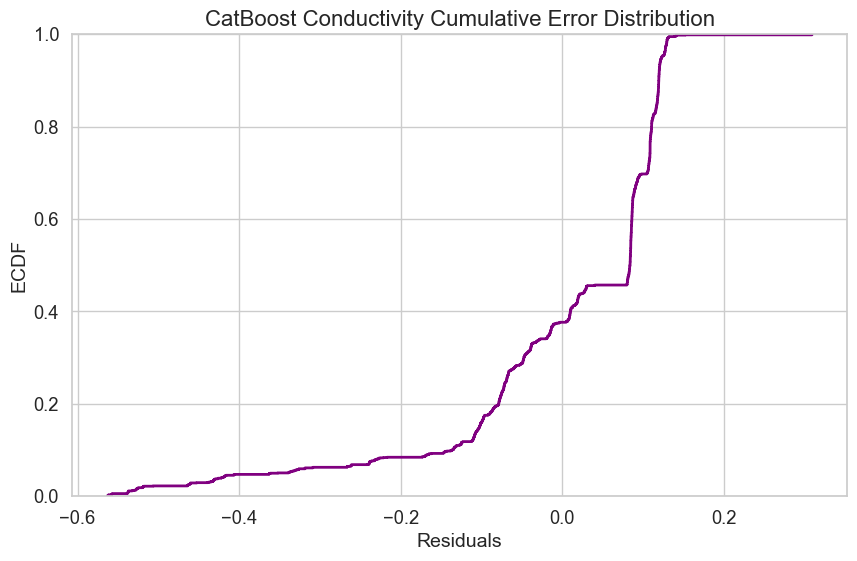

In [1]:
import pandas as pd
import numpy as np
import catboost as cb
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# ✅ Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# ✅ Remove duplicate rows
df.drop_duplicates(inplace=True)

# ✅ Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# ✅ Define columns to exclude
columns_to_exclude = ["elongation", "UTS", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["Conductivity"]

# ✅ Normalize numeric features
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(
    X.select_dtypes(include=["float64", "int64"])
)

# ✅ Encode categorical features
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# ✅ Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Define CatBoost hyperparameters for Conductivity
params_conductivity = {
    "iterations": 150,  # ✅ Fewer trees for controlled learning
    "learning_rate": 0.015,  # ✅ Lower learning rate for better generalization
    "depth": 1,  # ✅ Shallower trees to reduce overfitting
    "l2_leaf_reg": 25,  # ✅ Stronger L2 penalty
    "subsample": 0.4,  # ✅ Uses only 40% of data per iteration
    "colsample_bylevel": 0.4,  # ✅ Uses fewer features per iteration
    "random_seed": 42,
    "loss_function": "RMSE",
    "verbose": 50
}

# ✅ Train CatBoost model for Conductivity
cat_model_conductivity = cb.CatBoostRegressor(**params_conductivity)
cat_model_conductivity.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

# ✅ Predict on Test set
y_pred = cat_model_conductivity.predict(X_test)

# ✅ Metrics
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# ✅ Print Final Metrics
print("\n🔹 CatBoost Conductivity Regression Metrics:")
print(f"✅ R²: {r2:.4f}")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")
print(f"✅ MAPE: {mape:.2f}%")

# ✅ Residuals
residuals_conductivity = y_test - y_pred

# ✅ Visualizations
output_dir_conductivity = "catboost_conductivity_plots"
os.makedirs(output_dir_conductivity, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("CatBoost Conductivity Actual vs. Predicted")
plt.xlabel("Actual Conductivity")
plt.ylabel("Predicted Conductivity")
plt.savefig(f"{output_dir_conductivity}/CatBoost_Conductivity_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals_conductivity, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_pred, y=residuals_conductivity, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("CatBoost Conductivity Residual Plot")
plt.xlabel("Predicted Conductivity")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir_conductivity}/CatBoost_Conductivity_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals_conductivity, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals_conductivity.min(), residuals_conductivity.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals_conductivity.mean(), residuals_conductivity.std()), color="red", linewidth=2)
plt.title("CatBoost Conductivity Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir_conductivity}/CatBoost_Conductivity_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 4. Learning Curves
# ✅ Learning Curves
results_conductivity = cat_model_conductivity.get_evals_result()

# Print out the structure of the evaluation results to identify the correct keys
print(results_conductivity)

# Adjust to correct keys for plotting based on the actual structure of results_conductivity
plt.figure(figsize=(10, 6))
plt.plot(results_conductivity['learn']['RMSE'], '--', label='Training RMSE', color='blue', linewidth=2)
plt.plot(results_conductivity['validation']['RMSE'], '-', label='Validation RMSE', color='orange', linewidth=2)
plt.title("CatBoost Conductivity Learning Curves")
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.legend()
plt.savefig(f"{output_dir_conductivity}/CatBoost_Conductivity_Learning_Curves.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 5. Hyperparameter vs. Error Plot
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
errors_conductivity = []
for lr in learning_rates:
    temp_params = params_conductivity.copy()
    temp_params["learning_rate"] = lr
    model = cb.CatBoostRegressor(**temp_params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    y_pred_temp = model.predict(X_test)
    rmse_conductivity = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    errors_conductivity.append(rmse_conductivity)

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, errors_conductivity, marker='o', linewidth=2)
plt.title("CatBoost Conductivity Learning Rate vs. RMSE")
plt.xlabel("Learning Rate")
plt.ylabel("RMSE")
plt.savefig(f"{output_dir_conductivity}/CatBoost_Conductivity_Hyperparameter_vs_Error.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 6. Feature Importance using SHAP
# Create a SHAP explainer for the trained model
explainer_conductivity = shap.TreeExplainer(cat_model_conductivity)

# Calculate SHAP values for the test set
shap_values_conductivity = explainer_conductivity.shap_values(X_test)

# Create a DataFrame to store the feature names and their importance scores based on SHAP values
shap_importance = np.abs(shap_values_conductivity).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": shap_importance
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by="Importance", ascending=False).head(10)

# Plotting feature importance using SHAP values
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, color="navy")
plt.title("CatBoost Conductivity Feature Importance (SHAP Values)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig(f"{output_dir_conductivity}/CatBoost_Conductivity_Feature_Importance_SHAP.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 7. SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_conductivity, X_test, plot_type="bar", show=False, color='purple')
plt.title("CatBoost Conductivity SHAP Summary Plot")
plt.savefig(f"{output_dir_conductivity}/CatBoost_Conductivity_SHAP_Summary_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 8. Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals_conductivity, dist="norm", plot=plt)
plt.title("CatBoost Conductivity Q-Q Plot")
plt.savefig(f"{output_dir_conductivity}/CatBoost_Conductivity_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 9. Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals_conductivity, color="purple", linewidth=2)
plt.title("CatBoost Conductivity Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir_conductivity}/CatBoost_Conductivity_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()
